# 06 — Confidence & Abstention

**Experiments F01/F02/F04/F05/F06 (WBS T026-T027).** RAG (`05_rag_e2e.ipynb`) closed with 88.0% accuracy at v2 - a real, understood 9.3pt-ish gap from Oracle. The plan's next lever is confidence-based abstention: can the system recognize its own uncertain cases and route them differently, rather than answering everything with equal (over)confidence?

The plan's original design (Section 8) expected a confidence signal to clear ~0.7 AUROC and support hard abstention at >70% effectiveness. This notebook tests that assumption directly, entirely for free - it reuses the already-collected v2-prompt RAG predictions (T018) and re-derives retrieval scores by re-running the deterministic, local retrieval pipeline on the same 150-case sample. No new API calls.

In [1]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

from pipeline.viz_style import CATEGORICAL_SLOTS, apply_style, style_axes, savefig_kwargs
apply_style()

analysis = json.loads(Path("data/confidence_analysis.json").read_text())
print(f"F01 self-confidence AUROC:        {analysis['f01_self_confidence_auroc']:.3f}  (target ~0.7)")
print(f"F02 retrieval-score AUROC:        {analysis['f02_retrieval_score_auroc']:.3f}")
print(f"Extra: score-margin AUROC:        {analysis['extra_score_margin_auroc']:.3f}")
print(f"Extra: rule-agreement AUROC:      {analysis['extra_rule_agrees_auroc']:.3f}")
print(f"Best signal: {analysis['best_signal']} (AUROC={analysis['best_signal_auroc']:.3f})")

F01 self-confidence AUROC:        0.554  (target ~0.7)
F02 retrieval-score AUROC:        0.464
Extra: score-margin AUROC:        0.491
Extra: rule-agreement AUROC:      0.657
Best signal: rule_agrees (AUROC=0.657)


## F01: is the model's self-reported confidence calibrated?

AUROC alone can hide *why* a signal fails. The calibration table below - empirical accuracy inside each confidence bucket - shows exactly what's wrong: the model overwhelmingly reports confidence near 1.0, regardless of whether it's actually right.

In [2]:
calib_df = pd.DataFrame(analysis["f01_calibration"]).set_index("bin")
calib_df

,n,avg_confidence,empirical_accuracy
bin,,,
"[0.00, 0.50)",8,0.0,1.000000
"[0.70, 0.85)",4,0.8,0.250000
"[0.85, 0.95)",6,0.9,0.833333
"[0.95, 1.01)",132,1.0,0.893939


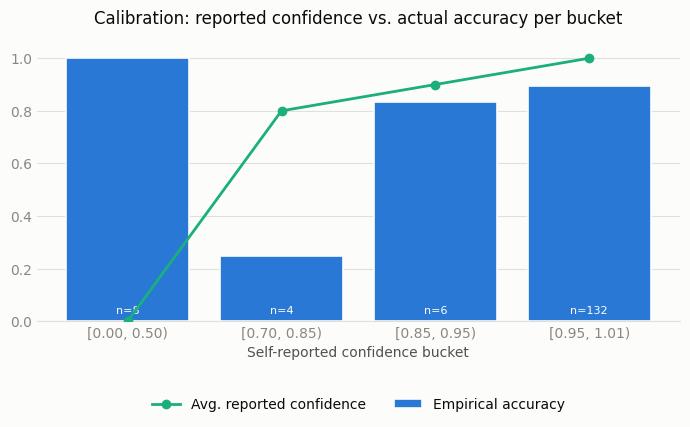

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(calib_df.index, calib_df["empirical_accuracy"], color=CATEGORICAL_SLOTS[0],
       edgecolor="#fcfcfb", linewidth=1.2, zorder=3, label="Empirical accuracy")
ax.plot(calib_df.index, calib_df["avg_confidence"], color=CATEGORICAL_SLOTS[2],
        marker="o", linewidth=2, zorder=4, label="Avg. reported confidence")
for i, n in enumerate(calib_df["n"]):
    ax.text(i, 0.03, f"n={n}", ha="center", fontsize=8, color="white")
ax.set_ylim(0, 1.1)
ax.set_xlabel("Self-reported confidence bucket")
ax.set_title("Calibration: reported confidence vs. actual accuracy per bucket")
style_axes(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2, frameon=False)
plt.tight_layout()
plt.savefig("results/comparisons/confidence_calibration.png", **savefig_kwargs())
plt.show()

**132 of 150 cases (88%) report confidence in [0.95, 1.0)** - the model is essentially always "certain," whether or not it's right (89.4% accurate in that giant bucket). The tiny buckets in between are noisy (n=4-8 each) and don't show a clean monotonic trend - if anything the [0.70, 0.85) bucket (n=4) is *worse* than the near-certain bucket. This is a known LLM failure mode: models asked to self-report a confidence field in structured JSON output tend to default to near-maximal values rather than genuinely calibrating - not a bug in how AUROC was computed here.

## F02: does the retrieval score do any better?

No - it's worse than chance (AUROC 0.464). One caveat worth being explicit about: the top score comes from two different scales depending on whether the rule-based match fired (T023 round 7) - a small Reciprocal-Rank-Fusion score (~1/60 scale) when it did, versus the cross-encoder's raw logit score when it didn't. Mixing those scales likely makes this signal noisier than a single consistent scale would be, but even the cleaner score-margin variant (top1 - top2 gap, AUROC 0.491) doesn't do meaningfully better - retrieval confidence just isn't a useful abstention signal here.

## The signal that actually has some power: rule-baseline agreement

Does `pipeline/rule_baseline.py`'s keyword classifier reach the same label as RAG? At AUROC 0.657 this is the best of everything tried - still short of the plan's 0.7 target, but a real, non-random signal.

In [4]:
sweep_df = pd.DataFrame(analysis["f04_threshold_sweep"])
sweep_df

,threshold,coverage,selective_accuracy,abstention_rate,abstention_effectiveness,n_accepted,n_abstained
0,0.000000,1.000000,0.880000,0.000000,NaN,150,0
1,0.111111,0.553333,0.939759,0.446667,0.19403,83,67
2,0.222222,0.553333,0.939759,0.446667,0.19403,83,67
3,0.333333,0.553333,0.939759,0.446667,0.19403,83,67
4,0.444444,0.553333,0.939759,0.446667,0.19403,83,67
5,0.555556,0.553333,0.939759,0.446667,0.19403,83,67
6,0.666667,0.553333,0.939759,0.446667,0.19403,83,67
7,0.777778,0.553333,0.939759,0.446667,0.19403,83,67
8,0.888889,0.553333,0.939759,0.446667,0.19403,83,67
9,1.000000,0.553333,0.939759,0.446667,0.19403,83,67


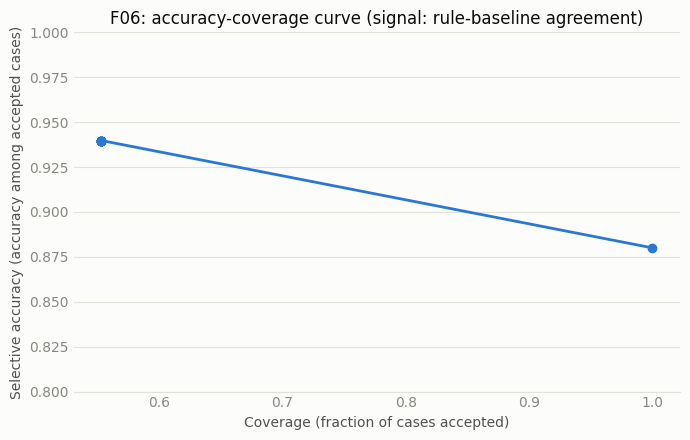

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sweep_df["coverage"], sweep_df["selective_accuracy"], marker="o",
        color=CATEGORICAL_SLOTS[0], linewidth=2, zorder=3)
ax.set_xlabel("Coverage (fraction of cases accepted)")
ax.set_ylabel("Selective accuracy (accuracy among accepted cases)")
ax.set_title("F06: accuracy-coverage curve (signal: rule-baseline agreement)")
ax.set_ylim(0.8, 1.0)
style_axes(ax)
plt.tight_layout()
plt.savefig("results/comparisons/accuracy_coverage_curve.png", **savefig_kwargs())
plt.show()

At rule-agreement (coverage 55.3%), selective accuracy is **94.0%**, a real lift over the 88.0% baseline. But F05's question is different: *if we abstain on the other 44.7%, how many of those would actually have been wrong?* Only **19.4%** - far short of the 70% target. The "disagreement" bucket is still **80.6% correct** on its own.

## F05 in plain terms: why hard abstention doesn't work here

Abstaining on every case where the rule disagrees would mean giving up an answer on 67 cases (of 150) to avoid ~13 wrong ones - discarding 54 correct answers to catch 13 incorrect ones. That's a bad trade for a product where showing *some* answer (with appropriate framing) is more useful than seeing "abstained" on cases that were actually fine.

Combining the two best signals (self-confidence==1.0 AND rule agreement) doesn't rescue this either:

In [6]:
print(f"Combined signal coverage:              {analysis['combined_coverage']:.3f}")
print(f"Combined signal selective accuracy:    {analysis['combined_selective_accuracy']:.3f}")
print(f"Combined signal abstention effectiveness: {analysis['combined_abstention_effectiveness']:.3f}")
print("\n(Rule-agreement alone: coverage=0.553, selective_acc=0.940, effectiveness=0.194 - combining doesn't help.)")

Combined signal coverage:              0.480
Combined signal selective accuracy:    0.931
Combined signal abstention effectiveness: 0.167

(Rule-agreement alone: coverage=0.553, selective_acc=0.940, effectiveness=0.194 - combining doesn't help.)


## Decision

**No tested signal justifies hard abstention.** Rather than force a threshold that would discard more correct answers than it catches incorrect ones, `pipeline/confidence.py` implements a softer routing decision:

- **ACCEPT** when the rule baseline agrees with the RAG prediction (55.3% of cases, 94.0% selective accuracy).
- **REVIEW** when it disagrees (44.7% of cases, still 80.6% correct on their own) - flagged for further investigation rather than either blindly accepted or abstained.

Self-reported confidence is recorded on every routing decision for logging/visibility, but does **not** gate the decision - T026 showed it's near-random (AUROC 0.554) and would let confidently-wrong answers straight through if trusted.

**This is exactly the argument for the selective agent (T028-T030), not a workaround for its absence.** The REVIEW-routed cases are only weakly, not strongly, more likely to be wrong - a further investigation step (the agent) is a much better fit for that population than a binary confidence gate that this analysis shows doesn't discriminate cleanly.

**Revisit if:** the agent experiments find REVIEW-routed cases don't actually benefit from investigation (would suggest rule-agreement isn't a useful routing signal after all), or a better confidence signal turns up later (log-probabilities if the API exposes them, or self-consistency sampling). Full ADR in `CLAUDE.md`'s Decisions Log.